### Imports

In [86]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import copy
from tqdm import tqdm

### Problem 1 (15 pts)
A 2015 study of tenure-track Computer Science professors at PhD-granting universities in the U.S. and Canada recorded the geographic region of each professor’s doctoral and faculty institutions. As a network, each directed edge $(u \to v)$ represents the movement of a person, from (doctoral) university $u$ to (faculty) university $v$, and nodes have a label that indicates which geographic region the corresponding university is located in.  

Using the regions as communities, the mixing matrix $M$ gives the fraction of edges that point from region $r$ (rows) to region $s$ (columns):

$$ M = 
\begin{bmatrix}
\text{Region} & \text{Northeast} & \text{Midwest} & \text{South} & \text{West} & \text{Canada} \\
\text{Northeast} & 0.119 & 0.053 & 0.074 & 0.055 & 0.022 \\
\text{Midwest} & 0.031 & 0.067 & 0.061 & 0.026 & 0.011 \\
\text{South} & 0.025 & 0.027 & 0.083 & 0.024 & 0.006 \\
\text{West} & 0.049 & 0.033 & 0.043 & 0.073 & 0.011 \\
\text{Canada} & 0.006 & 0.005 & 0.005 & 0.005 & 0.085
\end{bmatrix}
$$

Calculate and report:

1. The values $e_r$ and $a_r$ that appear in the definition of modularity $Q$ [see Eq. (7.58) in *Networks*].
2. The contribution $Q_r$ for each region to the total modularity $Q$.
3. The modularity $Q$ of the network with respect to regional flow of faculty.

What do you conclude about overall assortativity in this system, and about the way the different regions are coupled together?

**Hint:** You will need to convert this directed mixing matrix into an undirected one by adding the edges that point $r \to s$ with those that point $s \to r$. Note that the diagonal here represents single edges, so you’ll need to multiply by 2 to make it undirected.


In [84]:
# Given directed mixing matrix M
M = np.array([
    [0.119, 0.053, 0.074, 0.055, 0.022],
    [0.031, 0.067, 0.061, 0.026, 0.011],
    [0.025, 0.027, 0.083, 0.024, 0.006],
    [0.049, 0.033, 0.043, 0.073, 0.011],
    [0.006, 0.005, 0.005, 0.005, 0.085]
])

# Step 1: Create the undirected matrix M'
M_undirected = M + M.T
np.fill_diagonal(M_undirected, 2 * np.diag(M))  # Double the diagonal elements

# Step 2: Compute e_r (fraction of edges within each community)
e_r = np.diag(M_undirected)

# Step 3: Compute a_r (sum of each row in the undirected matrix)
a_r = np.sum(M_undirected, axis=1)

# Step 4: Compute Q_r for each region
Q_r = e_r - a_r**2

# Step 5: Compute total modularity Q
Q = np.sum(Q_r)

# Output the computed values

# format these into a pd dataframe
results_df = pd.DataFrame({
    'Region': ['Northeast', 'Midwest', 'South', 'West', 'Canada'],
    'Edge Fraction (e_r)': e_r,
    'Row Sum (a_r)': a_r,
    'Q_r': Q_r
})

print(results_df)
print(f'Total modularity Q: {Q}')

      Region  Edge Fraction (e_r)  Row Sum (a_r)       Q_r
0  Northeast                0.238          0.553 -0.067809
1    Midwest                0.134          0.381 -0.011161
2      South                0.166          0.431 -0.019761
3       West                0.146          0.392 -0.007664
4     Canada                0.170          0.241  0.111919
Total modularity Q: 0.005524000000000057


----
- The modularity $Q = 0.00552$ is very close to zero, indicating that there is very little assortative mixing by region. This means that professors are not significantly more likely to stay within the same geographic region when transitioning from a PhD institution to a faculty position.

- Canada has the largest positive $Q_r$, suggesting that there is a relatively stronger tendency for movement to remain within Canada.

- The Northeast has the most negative $Q_r$, indicating that faculty movement out of the Northeast is relatively high compared to how many stay within the region.

- The overall low modularity suggests that the different regions are strongly interconnected, with no strong preference for remaining within the same geographic region.

### Problem 2 (10 pts)
Consider an undirected “line graph” with $n$ vertices and $n - 1$ edges, like so:  

$$ v_1 \leftrightarrow v_2 \leftrightarrow v_3 \leftrightarrow \dots \leftrightarrow v_n \leftrightarrow v_{n-1} \leftrightarrow v_{n-2} $$

(a) Show mathematically that if we divide this network into any two contiguous groups, such that one group has $g$ connected vertices and the other has $n - g$, the modularity $Q$ takes the value:

$$
Q = \frac{3 - 4n + 4gn - 4g^2}{2(n - 1)^2}
$$


Problem 2 Answer


----
Modularity is defined as

$$
Q = \frac{1}{2m}\sum_{ij}(A_{ij} - \frac{k_i k_j}{2m}) \delta(c_i, c_j) = \sum_u (e_{uu} - a_u^2)
$$

Where $e_{uu}$ for each group
$$
e_1 = \frac{g-1}{n-1}, \quad e_2 = \frac{(n-g) - 1}{n-1}
$$ 

$$
\implies \sum_u e_{uu} = \frac{g-1}{n-1} + \frac{(n-g) - 1}{n-1} = \frac{n-2}{n-1}
$$

And $a_u$ for each group
$$
a_1 = \frac{2(g-1) +1}{2(n-1)} = \frac{2g-1}{2{n-1}}
$$

$$
a_2 = \frac{2(n-g-1)+1}{2(n-1)} = \frac{2(n-g)-1}{2(n-1)}
$$

$$
\implies \sum a_u^2 = a_1^2 + a_2^2 = \left( \frac{2g-1}{2(n-1)}\right) ^2 + \left( \frac{2(n-g)-1}{2(n-1)}\right) ^2
$$

$$
% = \frac{4g^2 - 4g + 1+ 4(n-g)^2 - 4(n-g) + 1}{4(n-1)^2}

% = \frac{4g^2 - 4g + 1 +4n^2 - 8ng + 4g^2 - 4n + 4g + 1}{4(n-1)^2} 

= \frac{8g^2 + 4n^2 - 8ng - 4n + 2}{4(n-1)^2} 
$$

$$
\implies Q = \frac{n-2}{n-1} - \frac{8g^2 + 4n^2 - 8ng - 4n + 2}{4(n-1)^2} 
$$

$$
% = \frac{4(n-1)(n-2) - (8g^2 + 4n^2 - 8ng - 4n + 2)}{4(n-1)^2} 
$$

$$
% = \frac{ 4n^2 - 12n + 8 - 8g^2 - 4n^2 + 8ng + 4n - 2}{4(n-1)^2} 
$$

$$
= \frac{-8n + 6 -8g^2 + 8ng}{4(n-1)^2}  = \frac{3 - 4n + 4gn - 4g^2}{2(n - 1)^2} \quad \blacksquare
$$


### Problem 3 

(12 pts) Use the $n = 9$ node network and $c = 2$ group partition $\vec {z}$ given below to complete the following calculations

(a) Using the stochastic block model (SBM), (i) tabulate and report the maximum likelihood mixing matrix $M$, and (ii) calculate and report the log-likelihood log $L$ of this network under that model

----
#### Problem 3(a) Solution

We are given a network with 9 nodes and a 2-group partition:

- Group 1: ${1, 2, 8, 9, 7}$
- Group 2: ${3, 4, 5, 6}$

The edge list:

$$
edges = [(1, 2), (1, 3), (1, 6), (1, 7), (1, 8), (1, 9), (3, 4), (3, 6), (4, 6), (5, 6)]
$$

The mixing matrix $M$ is a $2 \times 2$ matrix where:

$$
M_{rs} = \frac{e_{rs}}{n_{rs}} \quad \text{where} \quad e_{rs} = \sum_{i<j}^n A_{ij}\delta_{r,z_i}\delta_{s,z_j} \quad \text{and} \quad n_{rs} = \sum_{i<j}^n \delta_{r,z_i}\delta_{s,z_j}
$$


The log-likelihood function for SBM:

$$
\ln \mathcal{L} = \sum_{r,s} e_{rs} \ln M_{rs} + (n_{rs} - e_{rs})\ln(\frac{n_{rs} - e_{rs}}{n_{rs}})
$$

(i) Maximum Likelihood Mixing Matrix
$$
M = \begin{bmatrix} \frac{4}{10} & \frac{2}{20} \\ -- & \frac{4}{6} \end{bmatrix}
$$

(ii) Log-likelihood
$$
\ln \mathcal{L} = (4 \ln \frac{4}{10} + 6\ln \frac{6}{10}) + (2 \ln \frac{2}{20} + 18\ln \frac{18}{20}) + (4 \ln \frac{4}{6} + 2\ln \frac{2}{6})  \approx -17.051
$$

(b) Using the degree-corrected stochastic block model (DC-SBM), (i) tabulate and report the mixing matrix $\omega$ and group degrees $K$, and (ii) calculate and report the log-likelihood log $L$ of this network under that model.

----
Problem 3(b) Solution

We are given a network with 9 nodes and a 2-group partition same as in Problem 3(a):

The mixing matrix $\omega$ is a $2 \times 2$ matrix where:

$$
\omega_{rs} = \sum_{i,j=1}^n A_{ij}\delta_{z_i,r}\delta_{z_j,s} \quad \text{and} \quad K_r = \sum_s \omega_{rs} = \sum_i k_i \delta_{z_i, r}
$$

The log-likelihood function for DC-SBM:

$$
\ln \mathcal{L} = \sum_{rs} \omega_{rs} ln \frac{\omega_{rs}}{K_r K_s}
$$


(i) DC-SBM Mixing Matrix
$$
\omega = \begin{bmatrix} & O & T & K_r \\ O & 8 & 2 & 10 \\ T & 2 & 8 & 10\end{bmatrix}
$$

(ii) log-likelihood
$$
\ln \mathcal{L} = \sum_{rs} \omega_{rs} \ln \frac{\omega_{rs}}{K_r K_s} 

= (8 \ln \frac{8}{10 \times 10}) + (2 \ln \frac{2}{10 \times 10}) + (2 \ln \frac{2}{10 \times 10}) + (8 \ln \frac{8}{10 \times 10})

\approx -56.060
$$

(c) Comment on which model is more likely to generate the observed network.

----

Comparing the log-likelihoods of both models:

SBM Log-Likelihood: $\ln \mathcal{L} \approx -17.05$

DC-SBM Log-Likelihood: $\ln \mathcal{L} \approx -56.06$

Since the log-likelihood is significantly lower for the Degree-Corrected Stochastic Block Model (DC-SBM), this suggests that SBM better captures the structure of the observed network. This is likely because DC-SBM accounts for degree heterogeneity, which the standard SBM does not. Thus, the DC-SBM is less likely to have generated the observed network.

### Problem 4

(63 pts total) Detecting community structure. In this problem, you will implement and apply the locally greedy heuristic for estimating the DC-SBM, as a way to ﬁnd communities in a network. Because the algorithm has several parts, we will build it up in pieces.
Recall that the algorithm runs in phases, and begins with a random initial partition. When
a phase begins at $t = 0$, all nodes are “unfrozen.” At each step t in a phase, it freezes exactly one node and the phase ends when $t = n$ and all nodes are frozen. At each step of a phase, the algorithm considers all possible group-changes for all unfrozen nodes, of which there are $(n − t)(c − 1)$ such single-node moves. Of these possible moves, it makes a greedy choice and then “freezes” the node it moved. At the end of a phase, if the best of the n partitions it explored $z_*$ is better than the initial partition $z_0$, then it begins a new phase with $z_*$ as the initial partition and we unfreeze all the nodes. Otherwise, it halts and returns the current phase’s $z_0$.

To implement this algorithm, you will (a) ﬁrst write the core logic of taking a single step within a phase. Then, you will (b) wrap that logic in a loop over nodes to run a single phase. Next, you will (c) wrap the phase logic in a loop that runs the entire algorithm from start to finish once. Finally, you will (d) wrap your algorithm in a loop that will try multiple random partitions, reporting the best final result of the set. With this function in hand, you’ll then (e) apply it to some real-world networks and get some communities!

(a) (18 pts) Write a function `makeAMove()` that implements the core logic of the algorithm:

- Input: a graph $G$, a current partition $z_t$, a number of groups $c$, and a binary “is-Frozen” vector $f$ (if $f_i = 1$, then $i$ is “frozen”)
- This function should loop over the $n − t$ unfrozen nodes (those with $f_i = 0$) and $c - 1$ possible single-node moves for each of those nodes and compute a log-likelihood of each combination.
- Over that loop, it should track the single best log-likelihood $\mathcal{L}_*$ and the corresponding “best move,” i.e., a pair $(i, z_i)$ where $z_i$ is $i$’s new group label $r$.
- Output: the final $\mathcal{L}_*$ and the pair $(i, z_i)$ the represent the change to $z_t$ that would yield $\mathcal{L}_∗$.
- Apply `makeAMove()` to the simple graph $G$ in question ??, with $c = 3$, a random
input partition $z_t$, and $f_i = 0$ for all $i$ except $f_2 = 1$. Provide a visualization of (i) the input graph $G$ with its node labels $z_t$ and its log-likelihood under the DC-
SBM, and (ii) the graph $G$ with node labels after applying the best move found and
its DC-SBM log-likelihood.

Hint: after you move a node to its $c − 1$ alternative group assignments, don’t forget to put $i$ back in group $s$ before you go to the next unfrozen node.

In [108]:
def compute_dc_sbm_parameters(G, z):
    """
    Compute the parameters for the DC-SBM based on the current partition z.

    Parameters:
    - G: The graph (networkx Graph)
    - z: The current partition (numpy array of community assignments)

    Returns:
    - B: The block matrix
    - theta: The degree correction parameters
    """
    n = len(z)
    c = max(z) + 1  # Number of communities

    # Count the number of nodes in each community
    n_r = np.zeros(c, dtype=int)
    for r in range(c):
        n_r[r] = np.sum(z == r)

    # Calculate the degree of each node
    k = np.zeros(n)
    for i in range(n):
        k[i] = G.degree(i)

    # Calculate the total degree in each community
    k_r = np.zeros(c)
    for i in range(n):
        k_r[z[i]] += k[i]

    # Calculate the degree correction parameter theta
    theta = np.zeros(n)
    for i in range(n):
        if k_r[z[i]] > 0:
            theta[i] = k[i] / k_r[z[i]]
        else:
            theta[i] = 0

    # Calculate the block matrix B
    B = np.zeros((c, c))
    e_rs = np.zeros((c, c))

    for i, j in G.edges():
        r, s = z[i], z[j]
        e_rs[r, s] += 1
        if r != s:
            e_rs[s, r] += 1

    total_edges = G.number_of_edges()
    for r in range(c):
        for s in range(c):
            if k_r[r] > 0 and k_r[s] > 0:
                B[r, s] = e_rs[r, s] / (k_r[r] * k_r[s])
            else:
                B[r, s] = 0

    return B, theta


def compute_log_likelihood(G, z, B, theta):
    """
    Compute the log-likelihood of the graph G under the DC-SBM with parameters B and theta.

    Parameters:
    - G: The graph (networkx Graph)
    - z: The current partition (numpy array of community assignments)
    - B: The block matrix
    - theta: The degree correction parameters

    Returns:
    - log_likelihood: The log-likelihood of the graph under the DC-SBM
    """
    n = len(z)
    log_likelihood = 0

    # Sum over all pairs of nodes
    for i in range(n):
        for j in range(i + 1, n):
            r, s = z[i], z[j]

            # Probability of edge between i and j
            p_ij = theta[i] * theta[j] * B[r, s]

            # Clip probability to avoid numerical issues
            p_ij = max(1e-10, min(p_ij, 1 - 1e-10))

            # Add to log-likelihood
            if G.has_edge(i, j):
                log_likelihood += np.log(p_ij)
            else:
                log_likelihood += np.log(1 - p_ij)

    return log_likelihood


def makeAMove(G, z_t, c, f):
    """
    Make a move in the DC-SBM community detection algorithm.

    Parameters:
    - G: The graph (networkx Graph)
    - z_t: The current partition (numpy array of community assignments)
    - c: The number of communities
    - f: A binary vector indicating which nodes are frozen

    Returns:
    - best_L: The best log-likelihood found
    - best_move: The best move found (node, new group)
    """
    n = len(z_t)
    best_L = float("-inf")
    best_move = None

    # Compute the current parameters
    B, theta = compute_dc_sbm_parameters(G, z_t)

    # Compute the current log-likelihood
    current_L = compute_log_likelihood(G, z_t, B, theta)

    # Loop over all unfrozen nodes
    for i in range(n):
        if f[i] == 0:  # Only consider unfrozen nodes
            current_group = z_t[i]

            # Loop over all possible groups (excluding the current group)
            for r in range(c):
                if r != current_group:
                    # Make a copy of z_t and assign node i to group r
                    z_new = z_t.copy()
                    z_new[i] = r

                    # Compute the new parameters
                    B_new, theta_new = compute_dc_sbm_parameters(G, z_new)

                    # Compute the new log-likelihood
                    new_L = compute_log_likelihood(G, z_new, B_new, theta_new)

                    # If the new log-likelihood is better, update the best move
                    if new_L > best_L:
                        best_L = new_L
                        best_move = (i, r)

    # If no better move was found, return the current log-likelihood and None
    if best_move is None:
        return current_L, None

    return best_L, best_move


def runPhase(G, z_0, c):
    """
    Run a single phase of the DC-SBM community detection algorithm.

    Parameters:
    - G: The graph (networkx Graph)
    - z_0: The initial partition (numpy array of community assignments)
    - c: The number of communities

    Returns:
    - z_best: The best partition found in this phase
    - L_best: The log-likelihood of the best partition
    """
    n = len(z_0)
    z_t = z_0.copy()
    f = np.zeros(n, dtype=int)  # All nodes are unfrozen

    # Compute the initial log-likelihood
    B, theta = compute_dc_sbm_parameters(G, z_t)
    L_best = compute_log_likelihood(G, z_t, B, theta)
    z_best = z_t.copy()

    # Run n steps in this phase
    for t in range(n):
        # Make a move
        L_new, best_move = makeAMove(G, z_t, c, f)

        # If no better move was found, break
        if best_move is None:
            break

        # Update the partition
        i, r = best_move
        z_t[i] = r

        # Freeze the node
        f[i] = 1

        # Update the best partition if needed
        if L_new > L_best:
            L_best = L_new
            z_best = z_t.copy()

    return z_best, L_best


def runAlgorithm(G, z_0, c, max_phases=100):
    """
    Run the DC-SBM community detection algorithm.

    Parameters:
    - G: The graph (networkx Graph)
    - z_0: The initial partition (numpy array of community assignments)
    - c: The number of communities
    - max_phases: The maximum number of phases to run

    Returns:
    - z_final: The final partition
    - L_final: The log-likelihood of the final partition
    """
    z_t = z_0.copy()
    B, theta = compute_dc_sbm_parameters(G, z_t)
    L_t = compute_log_likelihood(G, z_t, B, theta)

    for phase in range(max_phases):
        # Run a phase
        z_star, L_star = runPhase(G, z_t, c)

        # If the new partition is better, start a new phase
        if L_star > L_t:
            z_t = z_star.copy()
            L_t = L_star
        else:
            # No improvement, halt the algorithm
            break

    return z_t, L_t


def multipleRandomStarts(G, c, num_starts=10, max_phases=100):
    """
    Run the DC-SBM community detection algorithm with multiple random starts.

    Parameters:
    - G: The graph (networkx Graph)
    - c: The number of communities
    - num_starts: The number of random starts
    - max_phases: The maximum number of phases to run for each start

    Returns:
    - z_best: The best partition found
    - L_best: The log-likelihood of the best partition
    """
    n = G.number_of_nodes()
    z_best = None
    L_best = float("-inf")

    for start in range(num_starts):
        # Generate a random initial partition
        z_0 = np.random.randint(0, c, size=n)

        # Run the algorithm
        z_final, L_final = runAlgorithm(G, z_0, c, max_phases)

        # Update the best partition if needed
        if L_final > L_best:
            L_best = L_final
            z_best = z_final.copy()

    return z_best, L_best


def plot_graph(G, z, title, log_likelihood=None, save_path=None):
    """
    Plot a graph with nodes colored according to their community assignments.

    Parameters:
    - G: The graph (networkx Graph)
    - z: The partition (numpy array of community assignments)
    - title: The title of the plot
    - log_likelihood: The log-likelihood of the partition (optional)
    - save_path: Path to save the plot (optional)
    """
    # Use Seaborn styling
    sns.set_style("whitegrid")

    # Define the colors based on community labels
    community_colors = [
        "red",
        "green",
        "blue",
        "yellow",
        "purple",
        "orange",
        "brown",
        "pink",
        "gray",
        "olive",
    ]
    node_colors = [
        community_colors[z[i] % len(community_colors)] for i in range(len(z))
    ]

    # Plot the graph
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)  # Layout for node positions
    nx.draw(
        G,
        pos,
        node_color=node_colors,
        with_labels=True,
        node_size=500,
        font_size=12,
        font_weight="bold",
        edge_color="gray",
    )

    # Set title with log-likelihood
    title_text = (
        f"{title}\nLog-likelihood: {log_likelihood:.4f}"
        if log_likelihood is not None
        else title
    )
    plt.title(title_text, fontsize=14)

    plt.tight_layout()

    # Save the figure if a path is provided
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_90215/2792879149.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


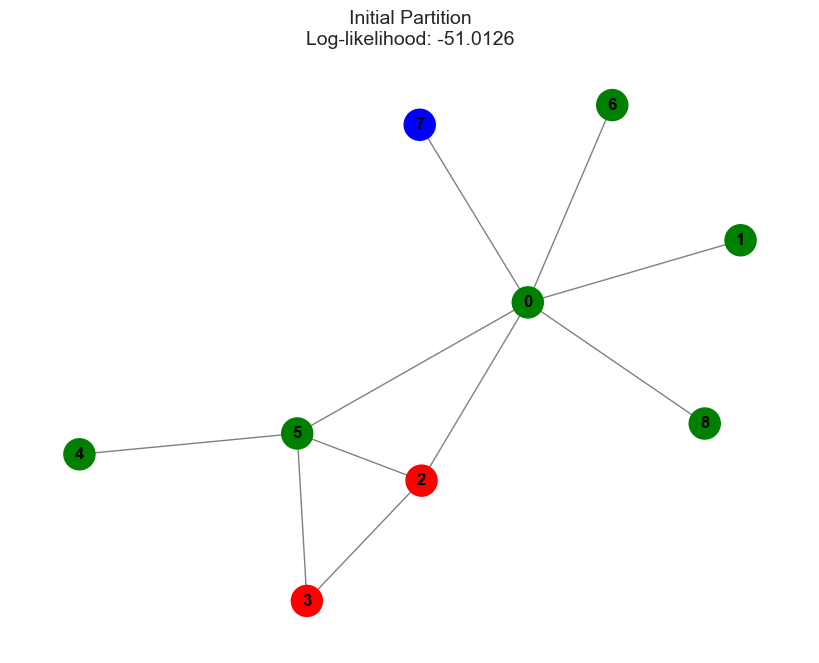

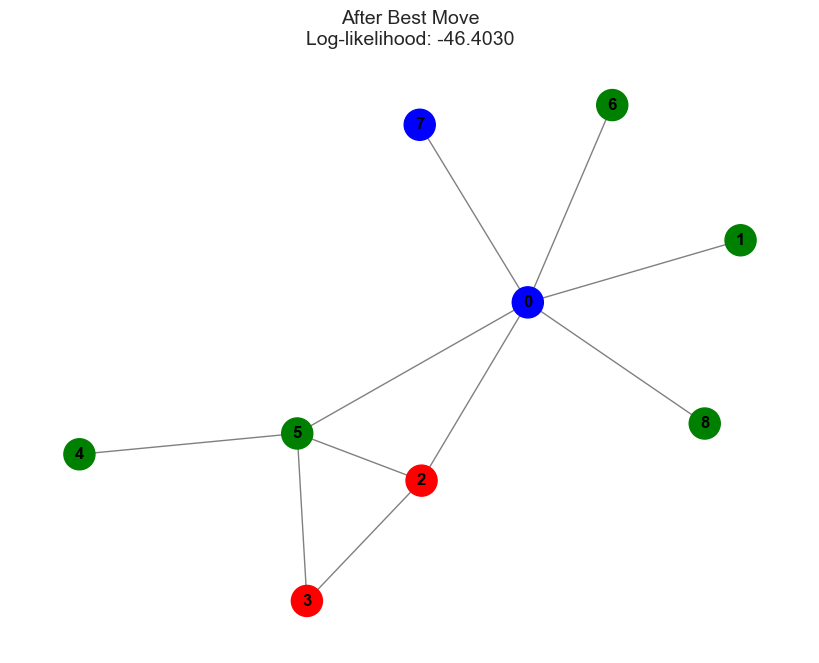

Best move: Move node 0 to community 2
Initial log-likelihood: -51.0126
New log-likelihood: -46.4030


In [109]:
# Create a simple graph
edges = [
    (0, 1),
    (0, 2),
    (0, 5),
    (0, 6),
    (0, 7),
    (0, 8),
    (2, 3),
    (2, 5),
    (3, 5),
    (4, 5),
]
G = nx.Graph()
G.add_edges_from(edges)
# Initial random partition
n = G.number_of_nodes()
c = 3
z_t = np.random.randint(0, c, size=n)
# Set node 2 as frozen
f = np.zeros(n, dtype=int)
f[2] = 1
# Compute initial log-likelihood
B, theta = compute_dc_sbm_parameters(G, z_t)
L_initial = compute_log_likelihood(G, z_t, B, theta)
# Plot the initial partition
plot_graph(G, z_t, "Initial Partition", L_initial, save_path="figures/4a_initial_partition.png")
# Make a move
L_new, best_move = makeAMove(G, z_t, c, f)
# Update the partition based on the best move
if best_move is not None:
    i, r = best_move
    z_new = z_t.copy()
    z_new[i] = r
    # Compute new log-likelihood
    B_new, theta_new = compute_dc_sbm_parameters(G, z_new)
    L_new = compute_log_likelihood(G, z_new, B_new, theta_new)
    # Plot the new partition
    plot_graph(G, z_new, "After Best Move", L_new, save_path="figures/4a_best_move.png")
    print(f"Best move: Move node {i} to community {r}")
    print(f"Initial log-likelihood: {L_initial:.4f}")
    print(f"New log-likelihood: {L_new:.4f}")


(b) (15 pts) Write a function `runOnePhase()` that runs a single phase from start to finish, starting with an input partition $z_0$ and and evaluates the algorithm’s convergence criteria:
- Input: a graph $G$, an initial partition $z_0$, and the number of groups $c$.
- Output: the best partition of the phase $z*$ and its corresponding DC-SBM log-likelihood $L_*$, a binary value $h$ that indicates whether the halting criteria was met or not, and a list $\ell$ that stores the $n + 1$ log-likelihood values for the $n + 1$ partitions considered in the phase (this part is purely so that we can make a nice visualization of the algorithm’s progression).
- Remember that when the phase begins, $f$ is all zeros (all nodes unfrozen), and we call `makeAMove()` to decide which node to “freeze” in a given step of the phase.
- Apply `runOnePhase()` to the simple graph $G$ in question ??, with $c = 3$, a random input partition $z_0$. Provide a visualization of (i) the input graph G with its node labels $z_0$ and its log-likelihood under the DC-SBM, (ii) the graph $G$ with node labels $z_*$ at the end of the phase and its DC-SBM log-likelihood $L_*$, and (iii) a plot of $\ell_t$ showing how the log-likelihood evolved over the course of the phase.

Hint: if you use python, you may need to use the `copy.deepcopy()` function to “save oﬀ” a separate copy of $z_t$ when you update $z_∗$, rather than a “shallow” copy (a pointer).

In [110]:
def runOnePhase(G, z_0, c):
    """
    Run a single phase of the DC-SBM community detection algorithm.

    Parameters:
    - G: The graph (networkx Graph)
    - z_0: The initial partition (numpy array of community assignments)
    - c: The number of communities

    Returns:
    - z_star: The best partition found in this phase
    - L_star: The log-likelihood of the best partition
    - h: A binary value indicating whether the halting criteria was met
    - l: A list of log-likelihood values for all partitions considered in the phase
    """
    n = len(z_0)
    z_t = copy.deepcopy(z_0)  # Use deep copy to avoid reference issues
    f = np.zeros(n, dtype=int)  # All nodes are unfrozen initially

    # Compute the initial log-likelihood
    B_0, theta_0 = compute_dc_sbm_parameters(G, z_0)
    L_0 = compute_log_likelihood(G, z_0, B_0, theta_0)

    # Initialize the best partition and its log-likelihood
    z_star = copy.deepcopy(z_0)
    L_star = L_0

    # Initialize the list of log-likelihoods
    l = [L_0]  # Start with the initial log-likelihood

    # Run n steps in this phase (one node gets frozen in each step)
    for t in range(n):
        # Make the best move
        L_new, best_move = makeAMove(G, z_t, c, f)

        # If no move is possible (all nodes are frozen or no better move exists)
        if best_move is None:
            break

        # Update the partition based on the best move
        i, r = best_move
        z_t[i] = r

        # Freeze the node we just moved
        f[i] = 1

        # Compute the new log-likelihood with updated parameters
        B_t, theta_t = compute_dc_sbm_parameters(G, z_t)
        L_t = compute_log_likelihood(G, z_t, B_t, theta_t)

        # Add the log-likelihood to our list
        l.append(L_t)

        # Update the best partition if needed
        if L_t > L_star:
            z_star = copy.deepcopy(z_t)
            L_star = L_t

    # Determine if halting criteria is met (if best partition is better than initial)
    h = 0 if L_star > L_0 else 1

    # If we didn't make n steps, pad the log-likelihood list with the last value
    while len(l) <= n:
        l.append(l[-1])

    return z_star, L_star, h, l


def plot_likelihood_evolution(l, title="Log-Likelihood Evolution During Phase", save_path = None):
    """
    Plot the evolution of the log-likelihood over the course of a phase.

    Parameters:
    - l: List of log-likelihood values
    - title: The title of the plot
    """
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(l)), l, "o-", linewidth=2, markersize=8)
    plt.xlabel("Step")
    plt.ylabel("Log-Likelihood")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_90215/2792879149.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


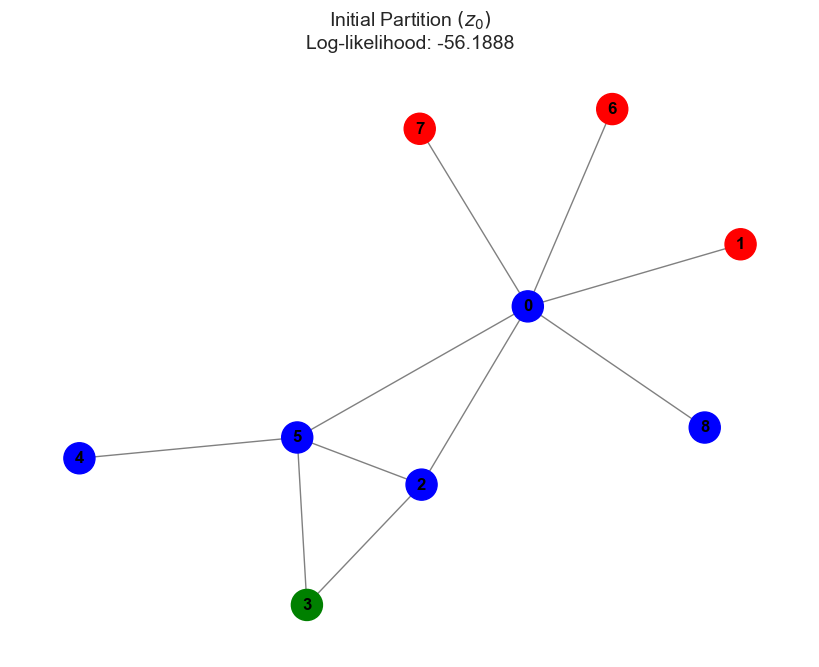

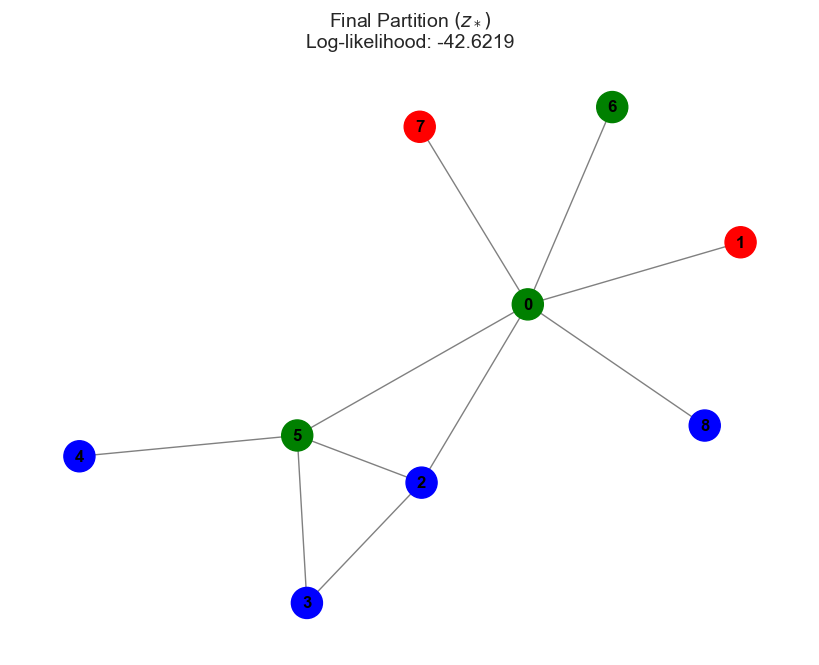

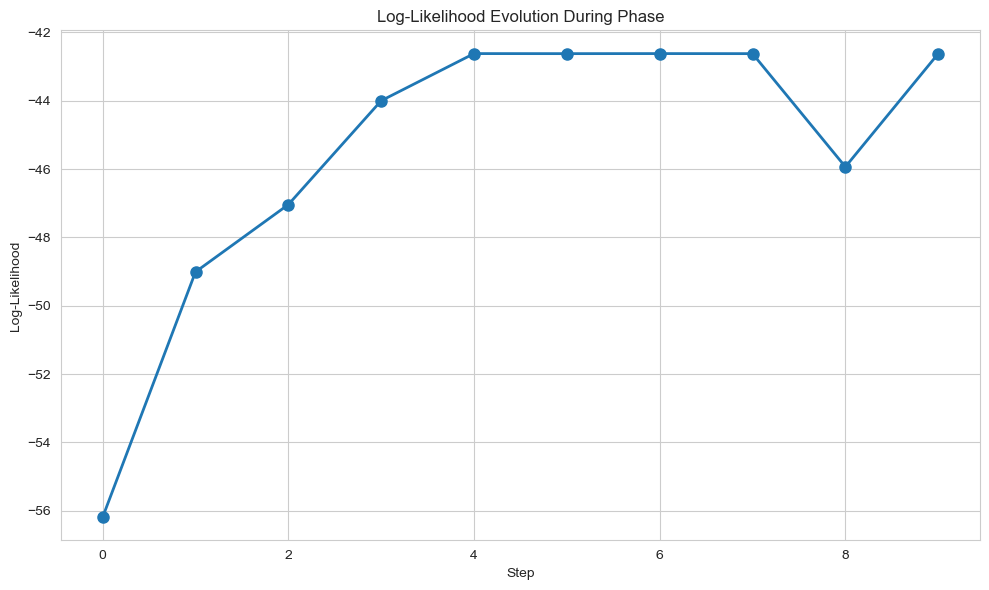

Initial partition log-likelihood: -56.1888
Best partition log-likelihood: -42.6219
Halting criteria met: False
Log-likelihood improved: True


In [111]:
# Create a simple graph
edges = [
    (0, 1),
    (0, 2),
    (0, 5),
    (0, 6),
    (0, 7),
    (0, 8),
    (2, 3),
    (2, 5),
    (3, 5),
    (4, 5),
]
G = nx.Graph()
G.add_edges_from(edges)

# Initial random partition
n = G.number_of_nodes()
c = 3

np.random.seed(42)  # For reproducibility
z_0 = np.random.randint(0, c, size=n)

# Compute initial log-likelihood
B_0, theta_0 = compute_dc_sbm_parameters(G, z_0)
L_0 = compute_log_likelihood(G, z_0, B_0, theta_0)

# Plot the initial partition
plot_graph(G, z_0, r"Initial Partition $(z_0)$", L_0, save_path="figures/4b_initial_partition.png")

# Run one phase
z_star, L_star, h, l = runOnePhase(G, z_0, c)

# Plot the final partition
plot_graph(G, z_star, r"Final Partition $(z_*)$", L_star, save_path="figures/4b_final_partition.png")

# Plot the evolution of the log-likelihood
plot_likelihood_evolution(l, save_path="figures/4b_likelihood_evolution.png")

# Print results
print(f"Initial partition log-likelihood: {L_0:.4f}")
print(f"Best partition log-likelihood: {L_star:.4f}")
print(f"Halting criteria met: {h == 1}")
print(f"Log-likelihood improved: {L_star > L_0}")


(c) (15 pts) Write a function `fitDCSBM()` that runs the full locally gready heuristic.
- Input: a graph $G$, a number of groups $c$, and the maximum of phases allowed $T$.
- Output: the best partition $z_∗$ and its log-likelihood $L_∗$ found across all phases, an integer pc that counts the number of phases used, and a list $\ell$ that stores the log- likelihood values for the $p_c (n + 1)$ steps taken across all phases (also purely to make a nice visualization of the algorithm’s progression).
- Apply `fitDCSBM()` to the simple graph $G$ in question ?? with $c = 3$ and $T = 30$ phases at most. Provide a visualization of (i) the graph $G$ with ﬁnal node labels $z_∗$ and its DC-SBM log-likelihood $L_∗$, (ii) a plot of $\ell_t$ showing how the log-likelihood evolved over the course of all the phases, and (iii) report the $\omega$ matrix and $K$ vector for the ﬁnal partition.
- Comment briefly on what you see in both the quality of the final partition and in the behavior of $\ell_t$.

Hint: How good a partition can you get? I got a log-likelihood of −48.14 or so

In [112]:
def fitDCSBM(G, c, T):
    """
    Run the full locally greedy heuristic for DC-SBM community detection.
    
    Parameters:
    - G: The graph (networkx Graph)
    - c: The number of communities
    - T: The maximum number of phases allowed
    
    Returns:
    - z_star: The best partition found across all phases
    - L_star: The log-likelihood of the best partition
    - pc: The number of phases used
    - l: A list of log-likelihood values for all steps taken across all phases
    """
    n = G.number_of_nodes()
    
    # Generate a random initial partition
    z_0 = np.random.randint(0, c, size=n)
    
    # Compute initial parameters and log-likelihood
    B_0, theta_0 = compute_dc_sbm_parameters(G, z_0)
    L_0 = compute_log_likelihood(G, z_0, B_0, theta_0)
    
    # Initialize best partition and log-likelihood
    z_best = copy.deepcopy(z_0)
    L_best = L_0
    
    # Initialize phase counter and log-likelihood list
    pc = 0
    l = []
    
    # Run phases until convergence or maximum phases reached
    for phase in range(T):
        # Run one phase
        z_phase, L_phase, h, l_phase = runOnePhase(G, z_best, c)
        
        # Add this phase's log-likelihoods to the overall list
        l.extend(l_phase)
        
        # Increment phase counter
        pc += 1
        
        # Check halting criteria
        if h == 1:  # If halting criteria is met (no improvement)
            break
        
        # Update the best partition
        z_best = copy.deepcopy(z_phase)
        L_best = L_phase
    
    # Compute the omega matrix and K vector for the final partition
    omega, K = compute_omega_and_K(G, z_best)
    
    return z_best, L_best, pc, l, omega, K

def compute_omega_and_K(G, z):
    """
    Compute the omega matrix and K vector for a given partition.
    
    Parameters:
    - G: The graph (networkx Graph)
    - z: The partition (numpy array of community assignments)
    
    Returns:
    - omega: The omega matrix
    - K: The K vector (community degree vector)
    """
    c = max(z) + 1  # Number of communities
    n = len(z)
    
    # Initialize the omega matrix and K vector
    omega = np.zeros((c, c))
    K = np.zeros(c)
    
    # Count the number of edges between communities
    for i, j in G.edges():
        r, s = z[i], z[j]
        omega[r, s] += 1
        if r != s:
            omega[s, r] += 1
    
    # Calculate the total degree of each community
    for i in range(n):
        K[z[i]] += G.degree(i)
    
    return omega, K

/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_90215/2792879149.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


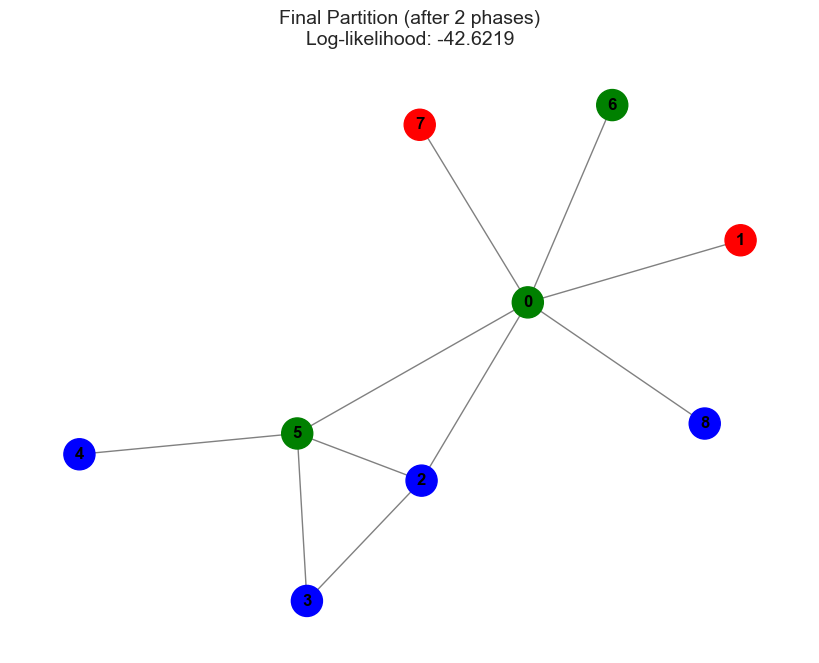

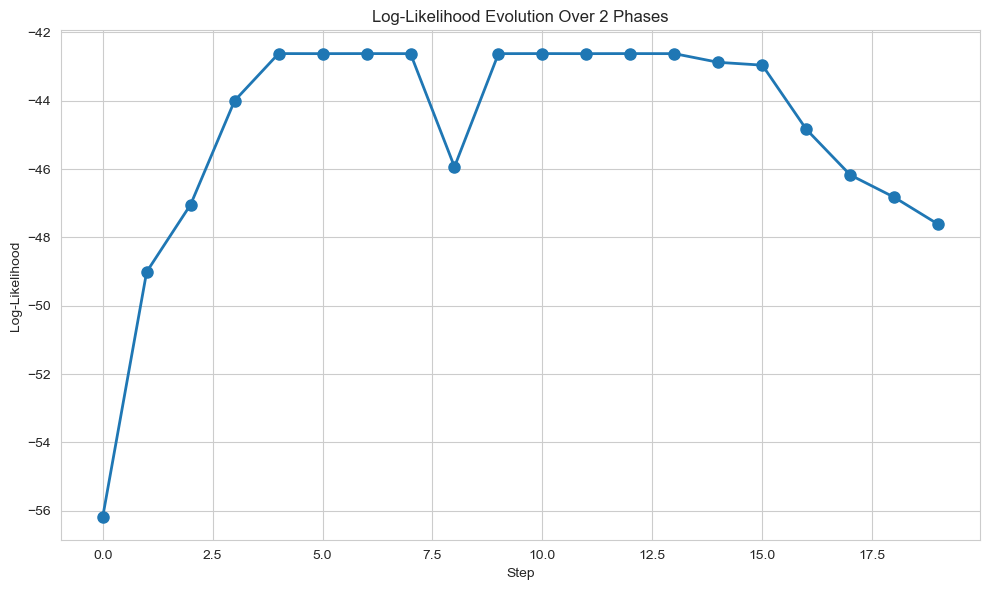

$\omega$ matrix (number of edges between communities):
[[0. 4. 1.]
 [4. 0. 5.]
 [1. 5. 0.]]
\n $\vec{K}$ (total degree of each community):
[5. 9. 6.]

Final log-likelihood: -42.6219
Number of phases used: 2

Comments on the results:
- The final partition has log-likelihood of -42.6219
- Community distribution:
  Community 0: 2 nodes
  Community 1: 3 nodes
  Community 2: 4 nodes
- Modularity of the partition: -0.3550
- The log-likelihood shows the following pattern:
  - The log-likelihood increased over the phases.


In [113]:
# Create a simple graph
edges = [
    (0, 1),
    (0, 2),
    (0, 5),
    (0, 6),
    (0, 7),
    (0, 8),
    (2, 3),
    (2, 5),
    (3, 5),
    (4, 5),
]
G = nx.Graph()
G.add_edges_from(edges)

# Set random seed for reproducibility
np.random.seed(42)

# Run the full algorithm
c = 3  # Number of communities
T = 30  # Maximum number of phases
z_star, L_star, pc, l, omega, K = fitDCSBM(G, c, T)

# Plot the final partition
plot_graph(G, z_star, f"Final Partition (after {pc} phases)", L_star, save_path="figures/4c_final_partition.png")

# Plot the evolution of the log-likelihood
plot_likelihood_evolution(l, f"Log-Likelihood Evolution Over {pc} Phases", save_path="figures/4c_likelihood_evolution.png")

# Print the omega matrix and K vector
print(r"$\omega$ matrix (number of edges between communities):")
print(omega)
print(r"\n $\vec{K}$ (total degree of each community):")
print(K)

# Print final log-likelihood
print(f"\nFinal log-likelihood: {L_star:.4f}")
print(f"Number of phases used: {pc}")

# Comment on the results
print("\nComments on the results:")
print("- The final partition has log-likelihood of {:.4f}".format(L_star))

# Analyze the community structure
print("- Community distribution:")
unique, counts = np.unique(z_star, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Community {u}: {c} nodes")

# Calculate modularity for additional insight
modularity = nx.community.modularity(
    G, [np.where(z_star == i)[0] for i in range(max(z_star) + 1)]
)
print(f"- Modularity of the partition: {modularity:.4f}")

# Analyze the likelihood evolution
print("- The log-likelihood shows the following pattern:")
if L_star > l[0]:
    print("  - The log-likelihood increased over the phases.")
else:
    print("  - The log-likelihood did not increase over the phases.")


(d) (15 pts) Write a function that repeatedly applies `fitDCSBM()` to the Zachary karate club network, and tracks the best output over repetitions. (Although the algorithm itself is deterministic, it begins at a random initial partition, and so re-running the algorithm many times allows us to sample diﬀerent local optima, looking for a good one.)
- Tinker with the number of repetitions needed to obtain the optimal $c = 2$ group partition described in the lecture notes.
- Provide a visualization of (i) the graph $G$ with the best node labels $z_∗$ across runs, and its DC-SBM log-likelihood $L_∗$, (ii) a plot of $\ell_t$ for the best run, showing how the log-likelihood evolved over the course of all the phases, and (iii) report the $\omega$ matrix and $K$ vector for the final partition.
- Comment briefly on how well your algorithm worked at this task, how many runs it took (a lot? a little? more than you expected? fewer?)
- Bask in the glory of having implemented and applied this amazing algorithm to reproduce the results of Karrer and Newman (2011)

In [114]:
def multi_run_fitDCSBM(G, c, T, num_runs):
    """
    Run the fitDCSBM algorithm multiple times and return the best result.
    
    Parameters:
    - G: The graph (networkx Graph)
    - c: The number of communities
    - T: The maximum number of phases allowed
    - num_runs: The number of times to run the algorithm
    
    Returns:
    - z_best: The best partition found across all runs
    - L_best: The log-likelihood of the best partition
    - pc_best: The number of phases used in the best run
    - l_best: The list of log-likelihood values for the best run
    - omega_best: The omega matrix for the best partition
    - K_best: The K vector for the best partition
    """
    best_L = float('-inf')
    best_z = None
    best_pc = 0
    best_l = []
    best_omega = None
    best_K = None
    
    # Run the algorithm multiple times
    for run in tqdm(range(num_runs)):
        z_star, L_star, pc, l, omega, K = fitDCSBM(G, c, T)
        
        # Update the best result if this run is better
        if L_star > best_L:
            best_L = L_star
            best_z = copy.deepcopy(z_star)
            best_pc = pc
            best_l = l.copy()
            best_omega = omega.copy()
            best_K = K.copy()
    
    return best_z, best_L, best_pc, best_l, best_omega, best_K

100%|██████████| 40/40 [00:52<00:00,  1.31s/it]
/var/folders/f2/lbj2f9h979b75rj33ps9wq780000gn/T/ipykernel_90215/2792879149.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


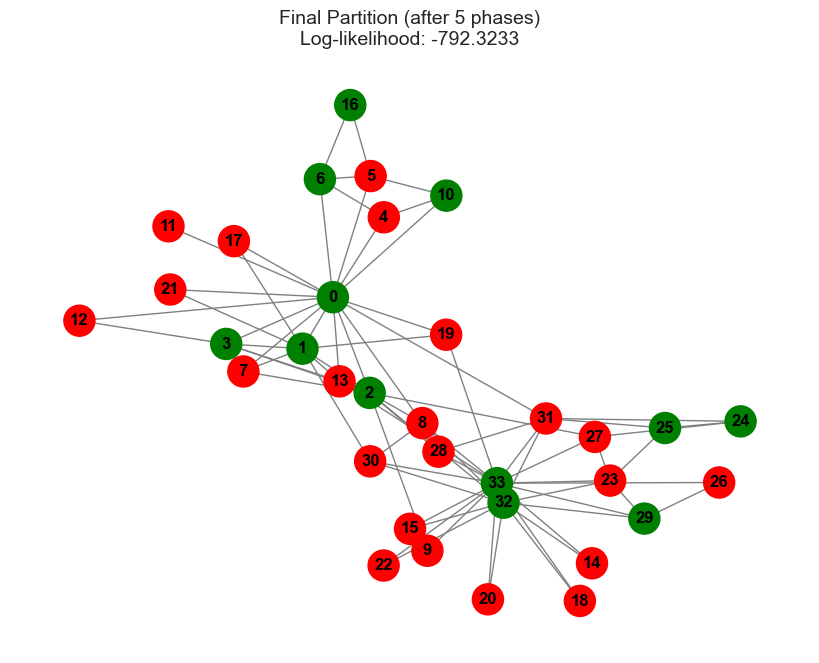

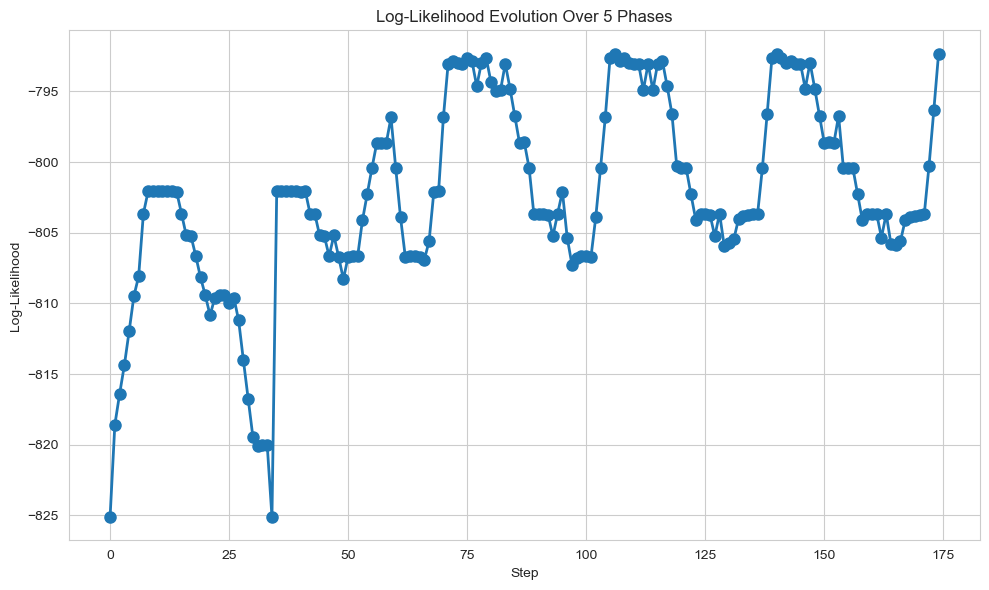

$\omega$ matrix (number of edges between communities):
[[ 3. 61.]
 [61. 14.]]
\n $\vec{K}$ (total degree of each community):
[67. 89.]

Final log-likelihood: -792.3233
Number of phases used: 5

Comments on the results:
- The final partition has log-likelihood of -792.3233
- Community distribution:
  Community 0: 22 nodes
  Community 1: 12 nodes
- Modularity of the partition: -0.2711
- The log-likelihood shows the following pattern:
  - The log-likelihood increased over the phases.


In [115]:
# Load the Zachary Karate Club network
G = nx.karate_club_graph()

# Set random seed for reproducibility
np.random.seed(42)

# Run the algorithm multiple times
c = 2   # Number of communities
T = 100  # Maximum number of phases
num_runs = 40  # Number of runs
z_best, L_best, pc_best, l_best, omega_best, K_best = multi_run_fitDCSBM(
    G, c, T, num_runs
)

# Plot the final partition
plot_graph(G, z_best, f"Final Partition (after {pc_best} phases)", L_best, save_path="figures/4d_final_partition.png")

# Plot the evolution of the log-likelihood
plot_likelihood_evolution(l_best, f"Log-Likelihood Evolution Over {pc_best} Phases", save_path="figures/4d_likelihood_evolution.png")

# Print the omega matrix and K vector
print(r"$\omega$ matrix (number of edges between communities):")
print(omega_best)
print(r"\n $\vec{K}$ (total degree of each community):")
print(K_best)

# Print final log-likelihood
print(f"\nFinal log-likelihood: {L_best:.4f}")
print(f"Number of phases used: {pc_best}")

# Comment on the results
print("\nComments on the results:")
print("- The final partition has log-likelihood of {:.4f}".format(L_best))

# Analyze the community structure
print("- Community distribution:")
unique, counts = np.unique(z_best, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Community {u}: {c} nodes")

# Calculate modularity for additional insight
modularity = nx.community.modularity(
    G, [np.where(z_best == i)[0] for i in range(max(z_best) + 1)]
)
print(f"- Modularity of the partition: {modularity:.4}")

# Analyze the likelihood evolution
print("- The log-likelihood shows the following pattern:")
if L_best > l_best[0]:
    print("  - The log-likelihood increased over the phases.")
else:
    print("  - The log-likelihood did not increase over the phases.")

### Problem 5
(10 pts extra credit) Reading the literature. Choose a paper from the Supplemental Reading list on the external course webpage. Read the whole paper. Think about what it says and what it finds. Read it again, if it’s not clear. Then, write a few sentences for each of the following questions in a way that clearly summarizes the work, and its context.

- What paper did you choose?
- What was the research question?
- What was the approach the authors took to answer that question?
- What did they do well?
- What could they have done better?
- What extensions can you envision?

Do not copy text from the paper itself; write your own summary, in your own words. (Using
terminology from the paper is okay, of course.) Be sure to answer each of the ﬁve questions. The amount of extra credit will depend on the accuracy and thoughtfulness of your answers

---
I read the paper "Projecting the transmission dynamics of SARS-CoV-2 through the postpandemic period" by Kissler et al. The research question in this paper focuses on projecting the transmission dynamics of SARS-CoV-2 in the post-pandemic period. The authors aimed to understand how seasonal variation, immunity duration, and cross-immunity with other coronaviruses might influence future outbreaks. They sought to determine whether SARS-CoV-2 would persist through recurrent outbreaks, be eradicated, or transition into an endemic seasonal virus, and they explored the potential need for long-term interventions such as social distancing.

To address this question, the authors developed a mathematical model based on historical data from human coronaviruses OC43 and HKU1. They incorporated factors like immunity waning, cross-immunity, and seasonal transmission patterns. The model was used to simulate different scenarios for SARS-CoV-2 transmission through 2025, analyzing how various intervention strategies, including intermittent social distancing, might help manage outbreaks while preventing healthcare system overload.

One of the paper’s strengths is its exceptional use of figures, which are well-crafted and curated to communicate the scope of the study clearly. The authors maintained consistent themes and colors across their visuals, which reflects deliberate effort and enhances comprehension. I often assess a paper’s figures first to get an intuitive sense of its content, and in this case, the figures alone provide a clear representation of the study’s methodology and findings. However, the study could have improved by incorporating more real-world validation of its model through emerging empirical data on SARS-CoV-2 immunity. Additionally, exploring regional differences in seasonality and transmission could have strengthened the analysis. Future extensions could include refining the model with updated serological data, integrating vaccine impact, or assessing new therapeutic strategies to mitigate recurrent outbreaks.
